## 2D spectrum

In [69]:
# w1, w1-w2
import math
import numpy as np
import matplotlib.pyplot as plt

deriv_mu = np.array([
    np.array([0.5, 0.2, 0.1]), 
    np.array([0.2, 0.5, 0.3]), 
    np.array([0.1, 0.3, 0.5])
])

deriv_alpha = np.array([
    np.array([0.5, 0.2, 0.1]), 
    np.array([0.2, 0.5, 0.3]), 
    np.array([0.1, 0.3, 0.5])
])

w = {'0': 3, '1': 5, '2': 7, '0+1': 0, '1+2': 10, '0+0': 0, '1+1': 0}

a, b = '0', '1'

# electrical anharmonicity
# @np.vectorize
def el_anh(w1, w2):
    """
    a, b, c - normal modes indices as strings
    w - dictionary of normal modes freqs, including some combination bands and overtones
        k:v '(str index or str combination)': freq
    w1 - range of w1 axis values
    w2 - range of w2 axis values
    w1mw2 = w1-w2
    deriv_mu, deriv_alpha - 2D arrays
    """
    # -----------------------------------------------------------------------
    deriv_mu = np.array([
        np.array([0.3, 0.1, 0.1]), 
        np.array([0.1, 0.3, 0.3]), 
        np.array([0.1, 0.3, 0.3])
    ])

    deriv_alpha = np.array([
        np.array([0.3, 0.2, 0.1]), 
        np.array([0.2, 0.3, 0.3]), 
        np.array([0.1, 0.3, 0.3])
    ])

    w = {'0': 3, '1': 5, '2': 7, '0+1': 0, '1+0': 0, 
                                 '1+2': 10, '2+1': 10, 
                                 '0+2': 0, '2+0': 0, '0+0': 0, '1+1': 0, '2+2': 0}

    a, b = '0', '1'
    Gamma = np.array([
        np.array([0.001, 0.001, 0.001]),
        np.array([0.001, 0.001, 0.001]),
        np.array([0.001, 0.001, 0.001])
    ])
    # -----------------------------------------------------------------------
    
    w1mw2 = w1-w2
    w_0 = 0
    # print(w1)
    totalres = np.zeros((len(w1), len(w2)))
    
    for a in ['0', '1', '2']:
        for b in ['0', '1', '2']:
            # print(a, b)
            res = 1/w[a]/w[b]
            term1 = deriv_mu[int(a), int(a)] * \
                deriv_alpha[int(b), int(b)] * deriv_mu[int(a), int(b)] / \
                (w[a+'+'+b]-w[a]-w1mw2 -Gamma[int(a), int(b)]) / (w_0-w[a]+w1 -Gamma[int(a), int(b)])
            
            totalres += res*term1
    # print(totalres)
    return totalres


def mech_anh(w1, w1mw2, w, a, b, c):
    res = 1/w[a]/w[b]/w[c]
    term1 = deriv_mu[a]*deriv_alpha[b]*deriv_mu[c] 
    term2 = 1/ (w[apb]-w[a]-w1mw2-Gamma[a, b]) / (w[0]-w[a])
    term3 = 1/ (w[apbpc]-w[0]) + 1/ (w[c] - w[apb])
    
    return res*term1

w1 = np.array([3, 8, 9])
w2 = np.array([2, 7, 11])
xx, yy = np.meshgrid(w1, w1+w2)

z = el_anh(xx, yy)**2
np.set_printoptions(suppress=True)
print(z)

[[16.19886978  0.59656228  0.00000014]
 [ 0.20059045  0.9603843   0.00000005]
 [ 0.08288484  0.00000019  0.0000001 ]]


In [91]:
import numpy as np
import matplotlib.pyplot as plt
   
def spectrum(w1, w2, w, option1=False, prt=False):
    
    if option1:
        X, Y = np.meshgrid(w1, w1-w2)
    else:
        X, Y = np.meshgrid(w1, w2)


    # compute the third dimension at each point on the grid
    Z = el_anh(X, Y)**2
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None

    # plot the points with the third dimension as color
    fig, ax = plt.subplots()
    fig.set_size_inches(12, 10)

    sc = ax.scatter(X.flatten(), Y.flatten(), c=Z.flatten(), cmap='viridis', s=200)

    ax.set_xlabel('w1', fontsize=18)

    if option1:
        ax.set_ylabel('w1-w2', fontsize=18)
    else:
        ax.set_ylabel('w2', fontsize=18)

    plt.colorbar(sc)
    plt.grid()

    # set the tick frequency on x and y axis
    ax.set_xticks(np.linspace(-2, 15, 18))
    ax.set_yticks(np.linspace(-2, 15, 18))
    ax.set_xlim(-1, 9)
    ax.set_ylim(-1, 9)
    for i in range(len(w1)):
        for j in range(len(w2)):
            ax.text(X[i, j], Y[i, j], f'({X[i, j]:.2f}, {Y[i, j]:.2f})',
                    ha='right', va='bottom')
    plt.show()


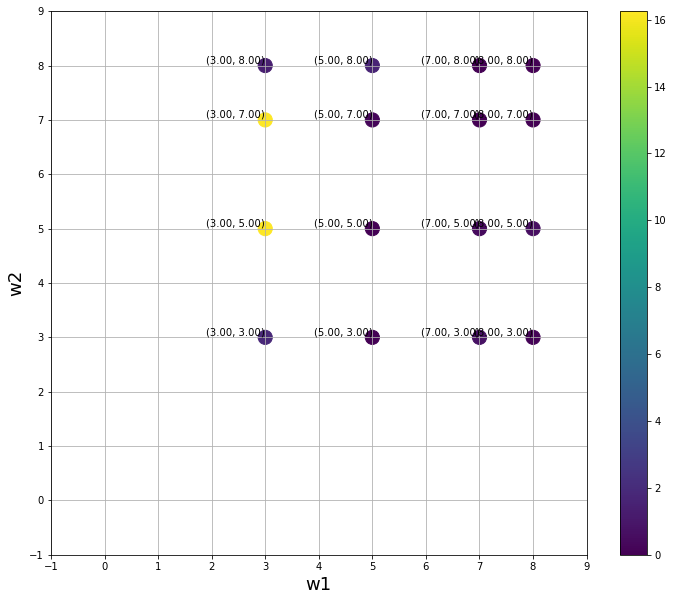

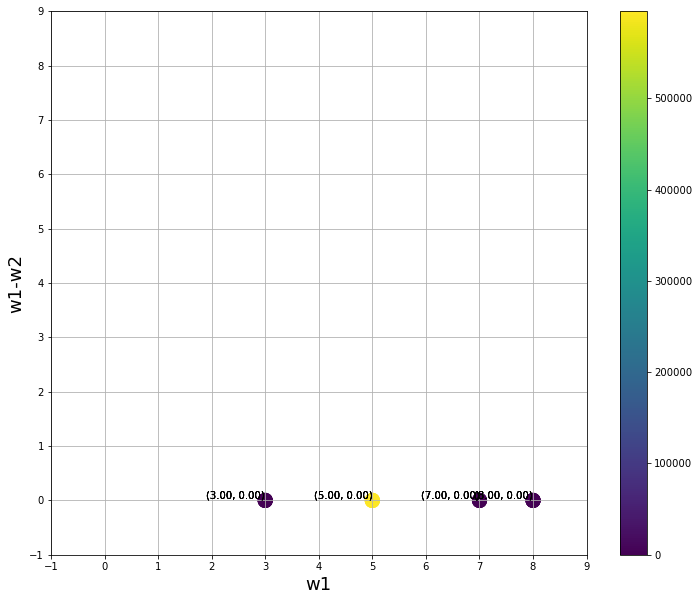

In [96]:
w2 = np.array([3, 5, 7, 8])
w1 = np.array([3, 5, 7, 8])

w = {'0': 3, '1': 5, '2': 8, 
                             '0+1': 0, '1+0': 0, 
                             '1+2': 0, '2+1': 0, 
                             '0+2': 0, '2+0': 0, 
                             '0+0': 0, '1+1': 0, '2+2': 0}

spectrum(w1, w2, w, option1=False)
spectrum(w1, w2, w, option1=True)